<div align="center">

# Machine Learning
## Regresión Líneal Multiple
<br><br><br><br><br>
---

### **Autor:** Anderson Jawarlan Vargas Ruiz
### **Profesor:** Danny Aldemar Jimenez Martin 
<br><br><br><br><br>
### **Universidad:** Fundación universitaria UNICAFAM
### **Facultad:** Ingeniería
### **Curso:** Inteligencia artificial II 5to Semestre
<br><br><br><br><br>
<br><br><br><br><br>
<p><center> Bogotá D.C
<p><center> 20 Febrero 2026

<br><br><br><br><br><br><br><br><br><br>

---

## **Resumen**
<p style="text-align: justify">Este documento contiene el desarrollo de ejercicios prácticos de machine learning y regresión lineal multiple o multi-variable, incluyendo representaciones gráficas mediante graficos de dispersión y mapa de calor con operaciones sobre modelo de entrenamiento y error cuadratico medio. Se valida la disponibilidad de los dataset mencionados en clase, se crea una hipotesis aleatoria para la verificación del entrenamiento y se grafica.

</div>

## Herramientas utilizadas

### Librerias

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split #

import seaborn as sns 

#Pendiente estudiar
#plt.style.use("seaborn-v0_8-whitegrid")

### Mostrar por completo los datos de los DataFrame

In [2]:
pd.set_option("display.max_rows", None) # Mostrar todas las filas
pd.set_option("display.max_columns", None) # Mostrar todas las columnas
pd.set_option("display.max_colwidth", None)# Ajustar el ancho de las columnas (para no cortar texto)
pd.set_option("display.width", None) # Evitar que se corte horizontalmente

### Validación de Datasets disponibles de SEABORN

In [3]:
Sets_Disponibles = pd.DataFrame(columns=["DataSet","Campos"])
for i in sns.get_dataset_names():
    for j in sns.load_dataset(i).columns:
        Sets_Disponibles.loc[len(Sets_Disponibles)] = [i,j]

Sets_Disponibles #Validación de Datassets Disponibles

,DataSet,Campos
0,anagrams,subidr
1,anagrams,attnr
2,anagrams,num1
3,anagrams,num2
4,anagrams,num3
5,anscombe,dataset
6,anscombe,x
7,anscombe,y
8,attention,Unnamed: 0
9,attention,subject


### Solución del Taller

In [4]:
pd.DataFrame(Sets_Disponibles["Campos"][Sets_Disponibles["DataSet"]=="car_crashes"])

,Campos
76,total
77,speeding
78,alcohol
79,not_distracted
80,no_previous
81,ins_premium
82,ins_losses
83,abbrev


<P style = "text-align: justify"> He seleccionado el dataset denominado car_crashes, es uno de los tantos que me llamo la atención, en este ejercicio entrenaremos nuestro modelo con los datos de accidentes de carros, validaremos los campos y seleccionaremos para nuestro modelo de regresion lineal multivarieble.

In [5]:
data = sns.load_dataset("car_crashes")
data.head(5) #Primeros Registros del data set para corroborar su comportamiento

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


In [6]:
campos_es = {
    'total':'Total',
    'speeding':'Exceso De Velocidad',
    'alcohol':'Alcohol',
    'not_distracted':'No Distraído',
    'no_previous':'Sin Antecedentes',
    'ins_premium':'INS Premium',
    'ins_losses':'INS_Pérdidas',
    'abbrev':'Abbrev'
}
Datos = data.rename(columns=campos_es)

In [7]:
print(f"Las filas del dataset: {Datos.shape[0]}, las columnas del dataset {Datos.shape[1]}")
Datos.describe()

Las filas del dataset: 51, las columnas del dataset 8


,Total,Exceso De Velocidad,Alcohol,No Distraído,Sin Antecedentes,INS Premium,INS_Pérdidas
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,15.790196,4.998196,4.886784,13.573176,14.004882,886.957647,134.493137
std,4.122002,2.017747,1.729133,4.508977,3.764672,178.296285,24.835922
min,5.900000,1.792000,1.593000,1.760000,5.900000,641.960000,82.750000
25%,12.750000,3.766500,3.894000,10.478000,11.348000,768.430000,114.645000
50%,15.600000,4.608000,4.554000,13.857000,13.775000,858.970000,136.050000
75%,18.500000,6.439000,5.604000,16.140000,16.755000,1007.945000,151.870000
max,23.900000,9.450000,10.038000,23.661000,21.280000,1301.520000,194.780000


## Matriz de correlación

In [8]:
Matriz_Cor = Datos.corr(numeric_only=True)
Matriz_Cor

,Total,Exceso De Velocidad,Alcohol,No Distraído,Sin Antecedentes,INS Premium,INS_Pérdidas
Total,1.000000,0.611548,0.852613,0.827560,0.956179,-0.199702,-0.036011
Exceso De Velocidad,0.611548,1.000000,0.669719,0.588010,0.571976,-0.077675,-0.065928
Alcohol,0.852613,0.669719,1.000000,0.732816,0.783520,-0.170612,-0.112547
No Distraído,0.827560,0.588010,0.732816,1.000000,0.747307,-0.174856,-0.075970
Sin Antecedentes,0.956179,0.571976,0.783520,0.747307,1.000000,-0.156895,-0.006359
INS Premium,-0.199702,-0.077675,-0.170612,-0.174856,-0.156895,1.000000,0.623116
INS_Pérdidas,-0.036011,-0.065928,-0.112547,-0.075970,-0.006359,0.623116,1.000000


## Mapa de Calor

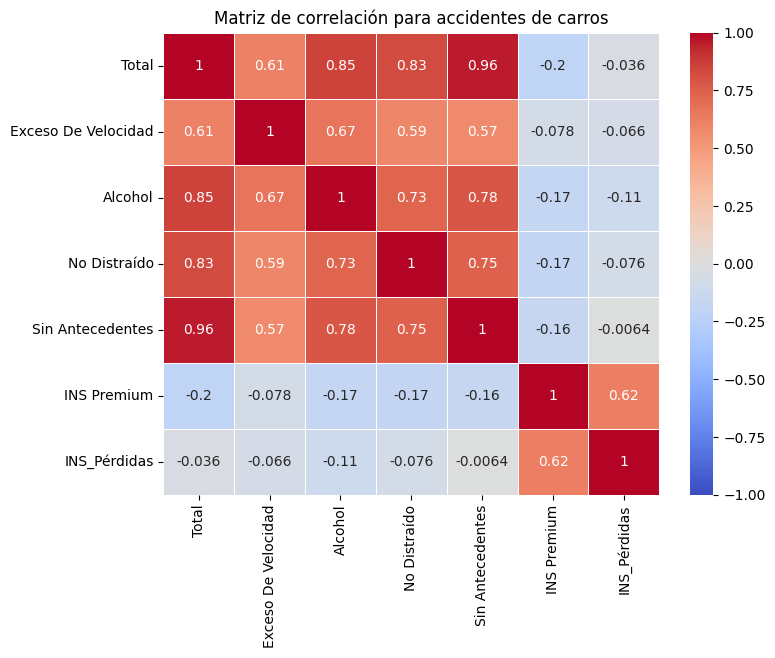

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(
    Matriz_Cor,
    annot=True,
    cmap="coolwarm",
    linewidths=0.4,
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Matriz de correlación para accidentes de carros")
plt.show()

## Pedicciones

<p style="text-align: justify"> Como podemos observar en nuestro mapa de calor, tenemos una relación fuerte entre el Total y % accidentes donde los conductores no tienen antecedentes, despues una correlación mas fuerte entre el % total y % de conductores accidentados por el alcohol, junto con conductores que no se distraen en las vias, en este orden de ideas, entraremos a realizar las predicciones del Total de accidentes con respecto a sin antecedentes, Alcohol y no distraidos. Los datos estimados los predeciremos con el 80% dejando así el 20% para la validación del modelo.

In [10]:
x = Datos[["Sin Antecedentes","Alcohol","No Distraído"]]
y = Datos["Total"]
x_ent, x_pru, y_ent, y_pru = train_test_split(x,y, test_size=0.2, random_state=42)

In [11]:
modelo = LinearRegression()
modelo.fit(x_ent,y_ent)

b = modelo.intercept_
m = modelo.coef_

y_pred = modelo.predict(x_pru)
ini_r2 = r2_score(y_pru, y_pred)
recm = mean_squared_error(y_pru,y_pred)**(1/2)

print("Coheficientes del modelo:", m)
print("Punto de intersepción:", b)
print("R2 del modelo:", ini_r2)
print("Raiz del erro cuadratico medio:",recm)

Coheficientes del modelo: [0.66013553 0.46595574 0.2298896 ]
Punto de intersepción: 1.0485200745240295
R2 del modelo: 0.9040615643328077
Raiz del erro cuadratico medio: 1.3172462906377977


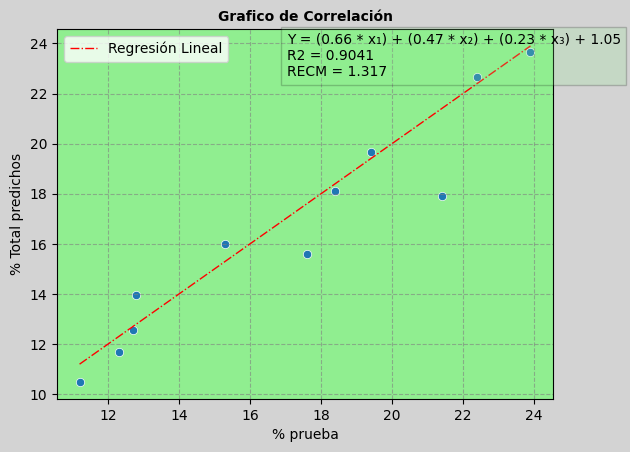

In [12]:
fig, ax = plt.subplots()

# Tu scatterplot y línea
sns.scatterplot(x=y_pru, y=y_pred, ax=ax)
line = [y_pru.min(), y_pru.max()]
ax.plot(line, line, "-.r", label="Regresión Lineal", linewidth=1)

ax.text(
    y_pru.mean(), y_pru.max()-1.2,
    f"Y = ({m[0]:.2f} * x\u2081) + ({m[1]:.2f} * x\u2082) + ({m[2]:.2f} * x\u2083) + {b:.2f}\nR2 = {ini_r2:.4f}\nRECM = {recm:.4}",
    fontsize=10, color="k",
    bbox=dict(facecolor="lightgreen", alpha=0.2)
)

ax.set_title("Grafico de Correlación", fontsize=10, fontweight="bold")
ax.set_xlabel("% prueba", fontsize=10)
ax.set_ylabel("% Total predichos", fontsize=10)

# Cuadrícula y leyenda
ax.grid(True, color="gray", linestyle="--", alpha=0.6)
ax.legend(loc="best", fontsize=10)

# Fondos personalizados
ax.set_facecolor("lightgreen") 
fig.patch.set_facecolor("lightgray")

plt.show()

### Hipotesis para predecir en nuestro modelo multi-variable

In [13]:
#Generamos 100 Datos aleatorios para validación de nuestro modelo
rangos = {
    "Sin Antecedentes": (x_ent["Sin Antecedentes"].min() - 3, x_ent["Sin Antecedentes"].max() + 5),
    "Alcohol": (x_ent["Alcohol"].min() - 3, x_ent["Alcohol"].max() + 5),
    "No Distraído": (x_ent["No Distraído"].min() - 3, x_ent["No Distraído"].max() + 5),
}

np.random.seed(42)  # para reproducibilidad

# Hipotesis
Datos_Hipo = {
    "Sin Antecedentes": np.random.uniform(rangos["Sin Antecedentes"][0], rangos["Sin Antecedentes"][1], 25),
    "Alcohol": np.random.uniform(rangos["Alcohol"][0], rangos["Alcohol"][1], 25),
    "No Distraído": np.random.uniform(rangos["No Distraído"][0], rangos["No Distraído"][1], 25),
}

# Pandas con datos encontrados de acuerdo al modelo.
Datos_Hipo_Pd = pd.DataFrame(Datos_Hipo)

# Predicción Mediante f(x) = (m1*x1) + (m2*x2) + (m3*x3) + b
Datos_Hipo_Pd["f(x)"] = (
    (m[0] * Datos_Hipo_Pd["Sin Antecedentes"]) + (m[1] * Datos_Hipo_Pd["Alcohol"]) + (m[2] * Datos_Hipo_Pd["No Distraído"])  + b
)

#PRedicción del Modelo
Datos_Hipo_Pd["Predicción Modelo"] = modelo.predict(pd.DataFrame(Datos_Hipo))

#Datos para graficar
y_H = np.array(Datos_Hipo_Pd["f(x)"])

#Tabla de Muestra
Datos_Hipo_Pd

,Sin Antecedentes,Alcohol,No Distraído,f(x),Predicción Modelo
0,11.441762,11.505219,27.861714,20.367675,20.367675
1,24.581990,1.876635,22.751715,23.380777,23.380777
2,19.593854,7.049585,27.071093,23.491277,23.491277
3,16.553005,8.335258,25.897168,21.813098,21.813098
4,6.458161,-0.643123,18.094214,9.171786,9.171786
5,6.457611,8.584075,26.607933,15.428105,15.428105
6,4.224655,1.397269,4.707494,5.570634,5.570634
7,22.654013,-0.337227,7.532234,17.577689,17.577689
8,16.609029,14.197423,3.570528,19.448928,19.448928
9,19.048303,14.472819,10.931356,22.879680,22.879680


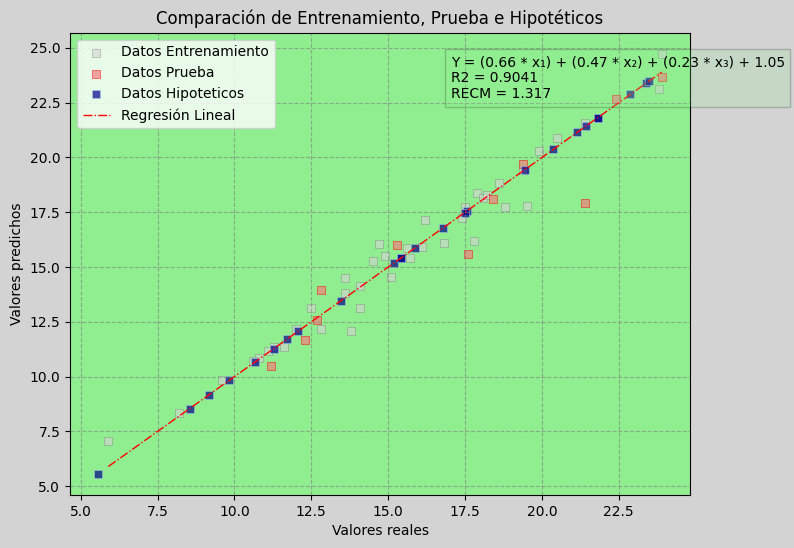

In [14]:
fig, ax = plt.subplots(figsize=(8,6))

# Datos de entrenamiento
sns.scatterplot(x=y_ent, y=modelo.predict(x_ent), ax=ax, 
                label="Datos Entrenamiento", color="lightgray", alpha=0.6, 
                marker="s", edgecolor="gray"
                )

# Datos de prueba
sns.scatterplot(x=y_pru, y=y_pred, ax=ax, 
                label="Datos Prueba", color="lightcoral", alpha=0.7, 
                marker="s", edgecolor="red"
                )

# Datos hipotéticos
sns.scatterplot(x=Datos_Hipo_Pd["f(x)"], y=modelo.predict(pd.DataFrame(Datos_Hipo)), ax=ax, 
                label="Datos Hipoteticos", color="darkblue", alpha=0.7, 
                marker="s", edgecolor="lightblue"
                )

# Línea de referencia
line = [y.min(), y.max()]
ax.plot(line, line, "-.r", label="Regresión Lineal", linewidth=1)

ax.text(
    y_pru.mean(), y_pru.max()-1.2,
    f"Y = ({m[0]:.2f} * x\u2081) + ({m[1]:.2f} * x\u2082) + ({m[2]:.2f} * x\u2083) + {b:.2f}\nR2 = {ini_r2:.4f}\nRECM = {recm:.4}",
    fontsize=10, color="k",
    bbox=dict(facecolor="lightgreen", alpha=0.2)
)

ax.set_title("Comparación de Entrenamiento, Prueba e Hipotéticos")
ax.set_xlabel("Valores reales")
ax.set_ylabel("Valores predichos")
ax.legend()
#ax.grid(True, linestyle="-", alpha=0.6)

# Cuadrícula y leyenda
ax.grid(True, color="gray", linestyle="--", alpha=0.6)
ax.legend(loc="best", fontsize=10)

# Fondos personalizados
ax.set_facecolor("lightgreen") 
fig.patch.set_facecolor("lightgray")

plt.show()